# SpinTwin
## A Simulation-Based Digital Twin for Ring-Spinning Monitoring, Predictive Quality, and Maintenance Decision Support

## 1. Project Overview

SpinTwin is a simulation-based digital-twin prototype for ring-spinning manufacturing. The system models spindle-level operating states, tracks end-break events and downtime, estimates machine utilization, detects abnormal spindle behavior, predicts yarn-quality risk, and provides maintenance-oriented decision support.

The current implementation uses simulated manufacturing and quality data and is intended as a research and demonstration prototype rather than a validated industrial deployment.

### Project Objectives

- Simulate spindle-level ring-frame operation.
- Track machine state, end breaks, and downtime.
- Monitor machine utilization.
- Detect abnormal spindle behavior.
- Predict yarn-quality risk using machine learning.
- Simulate gradual process degradation and early warning.
- Prioritize spindle maintenance.
- Integrate monitoring and predictive analytics into a live dashboard.

## 2. Imports and Configuration

In [1]:
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime, timedelta
from IPython.display import clear_output, display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

random.seed(42)
np.random.seed(42)

number_of_spindles = 20
number_of_time_steps = 120

## 3. Ring-Frame Process Simulation

A simplified ring-frame environment is simulated using multiple spindle-level operating states. Each spindle can run normally or enter a stopped state following a simulated end-break event.

In [2]:
spindle_health = {}

for spindle_id in range(1, number_of_spindles + 1):

    if spindle_id in [5, 12, 17]:
        health = "High Risk"

    elif spindle_id in [3, 8, 15]:
        health = "Medium Risk"

    else:
        health = "Healthy"

    spindle_health[spindle_id] = health


failure_probability = {
    "Healthy": 0.01,
    "Medium Risk": 0.04,
    "High Risk": 0.10
}

## 4. Stateful Spindle Monitoring

Each spindle maintains a persistent state. When an end break occurs, the spindle remains stopped for a simulated recovery period before returning to operation.

In [3]:
time_series_data = []

start_time = datetime.now()

spindle_states = {}

for spindle_id in range(1, number_of_spindles + 1):

    spindle_states[spindle_id] = {
        "status": "Running",
        "downtime_remaining": 0
    }


for t in range(number_of_time_steps):

    current_time = start_time + timedelta(seconds=t)

    for spindle_id in range(1, number_of_spindles + 1):

        state = spindle_states[spindle_id]

        health = spindle_health[spindle_id]
        probability = failure_probability[health]

        if state["downtime_remaining"] > 0:

            spindle_speed = 0
            status = "Stopped"

            state["downtime_remaining"] -= 1

        else:

            end_break = random.random() < probability

            if end_break:

                spindle_speed = 0
                status = "Stopped"

                state["downtime_remaining"] = random.randint(2, 5)

            else:

                spindle_speed = random.randint(15000, 18000)
                status = "Running"

        state["status"] = status

        row = {
            "timestamp": current_time,
            "spindle_id": spindle_id,
            "health_condition": health,
            "speed_rpm": spindle_speed,
            "status": status,
            "failure_probability": probability
        }

        time_series_data.append(row)


df_health = pd.DataFrame(time_series_data)

df_health.head()

,timestamp,spindle_id,health_condition,speed_rpm,status,failure_probability
0,2026-09-12 14:32:19.548229,1,Healthy,15102,Running,0.01
1,2026-09-12 14:32:19.548229,2,Healthy,16003,Running,0.01
2,2026-09-12 14:32:19.548229,3,Medium Risk,15419,Running,0.04
3,2026-09-12 14:32:19.548229,4,Healthy,17233,Running,0.01
4,2026-09-12 14:32:19.548229,5,High Risk,0,Stopped,0.10


## 5. End-Break and Downtime Detection

A true end-break event is defined as a transition from a running spindle state to a stopped spindle state. This avoids counting every stopped time step as a separate failure event.

In [4]:
df_health["previous_status"] = (
    df_health
    .groupby("spindle_id")["status"]
    .shift(1)
)

df_health["end_break_event"] = (
    (df_health["previous_status"] == "Running")
    &
    (df_health["status"] == "Stopped")
)

In [5]:
spindle_performance = (
    df_health
    .groupby("spindle_id")
    .agg(
        total_end_breaks=("end_break_event", "sum"),
        downtime_seconds=(
            "status",
            lambda x: (x == "Stopped").sum()
        ),
        average_running_speed_rpm=(
            "speed_rpm",
            lambda x: x[x > 0].mean()
        )
    )
    .reset_index()
)

spindle_performance = spindle_performance.sort_values(
    "total_end_breaks",
    ascending=False
)

spindle_performance.head(10)

,spindle_id,total_end_breaks,downtime_seconds,average_running_speed_rpm
16,17,8,40,16497.575000
11,12,6,27,16417.032258
4,5,5,34,16471.558140
2,3,4,16,16502.913462
5,6,3,12,16453.527778
7,8,3,14,16470.707547
14,15,3,20,16585.860000
10,11,2,9,16699.819820
18,19,2,4,16435.025862
9,10,2,8,16468.187500


## 6. Machine Utilization Analysis

Machine-level utilization is estimated from the number of running spindles relative to the total number of spindles at each time step.

In [6]:
machine_summary = (
    df_health
    .groupby("timestamp")
    .agg(
        total_spindles=("spindle_id", "count"),
        running_spindles=(
            "status",
            lambda x: (x == "Running").sum()
        ),
        stopped_spindles=(
            "status",
            lambda x: (x == "Stopped").sum()
        ),
        average_speed_rpm=("speed_rpm", "mean")
    )
    .reset_index()
)

machine_summary["utilization_percent"] = (
    machine_summary["running_spindles"]
    /
    machine_summary["total_spindles"]
) * 100

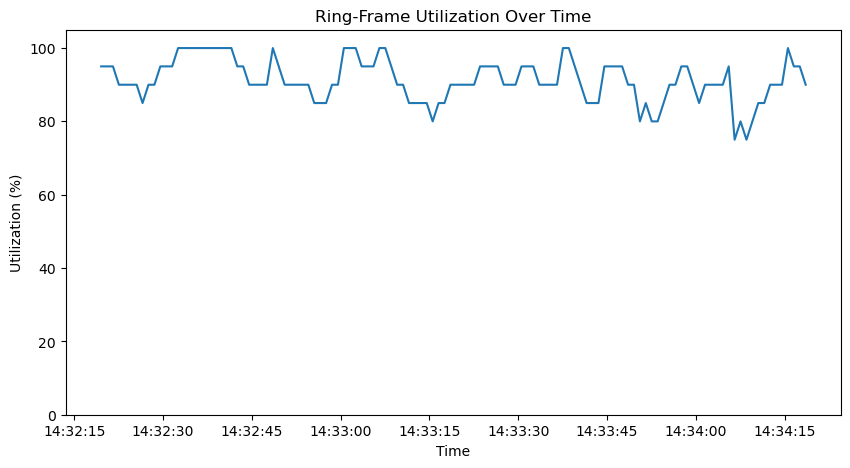

In [7]:
plt.figure(figsize=(10, 5))

plt.plot(
    machine_summary["timestamp"],
    machine_summary["utilization_percent"]
)

plt.xlabel("Time")
plt.ylabel("Utilization (%)")
plt.title("Ring-Frame Utilization Over Time")
plt.ylim(0, 105)

plt.show()

## 7. Spindle-Level Anomaly Detection

Operational features are extracted for each spindle and analyzed using Isolation Forest to identify spindles whose behavior differs substantially from the rest of the machine.

In [8]:
spindle_features = (
    df_health
    .groupby("spindle_id")
    .agg(
        total_end_breaks=("end_break_event", "sum"),
        average_speed_rpm=("speed_rpm", "mean"),
        speed_std_rpm=("speed_rpm", "std"),
        stopped_time=(
            "status",
            lambda x: (x == "Stopped").sum()
        )
    )
    .reset_index()
)

spindle_features["downtime_percent"] = (
    spindle_features["stopped_time"]
    / number_of_time_steps
) * 100

In [9]:
anomaly_feature_columns = [
    "total_end_breaks",
    "average_speed_rpm",
    "speed_std_rpm",
    "downtime_percent"
]

X_anomaly = (
    spindle_features[anomaly_feature_columns]
    .fillna(0)
)

scaler = StandardScaler()

X_anomaly_scaled = scaler.fit_transform(
    X_anomaly
)

anomaly_model = IsolationForest(
    contamination=0.15,
    random_state=42
)

anomaly_model.fit(
    X_anomaly_scaled
)

spindle_features["anomaly_prediction"] = (
    anomaly_model.predict(
        X_anomaly_scaled
    )
)

spindle_features["anomaly_status"] = (
    spindle_features["anomaly_prediction"]
    .map({
        1: "Normal",
        -1: "Anomaly"
    })
)

spindle_features["anomaly_score"] = (
    anomaly_model.decision_function(
        X_anomaly_scaled
    )
)

spindle_features.sort_values(
    "anomaly_score"
)

,spindle_id,total_end_breaks,average_speed_rpm,speed_std_rpm,stopped_time,downtime_percent,anomaly_prediction,anomaly_status,anomaly_score
16,17,8,10998.383333,7843.849117,40,33.333333,-1,Anomaly,-0.133100
4,5,5,11804.616667,7485.084088,34,28.333333,-1,Anomaly,-0.048970
11,12,6,12723.200000,6929.483434,27,22.500000,-1,Anomaly,-0.032786
14,15,3,13821.550000,6258.006308,20,16.666667,1,Normal,0.005786
13,14,0,16586.925000,841.125698,0,0.000000,1,Normal,0.024222
0,1,0,16596.775000,906.775675,0,0.000000,1,Normal,0.036828
2,3,4,14302.525000,5691.366062,16,13.333333,1,Normal,0.039240
15,16,0,16523.866667,936.588391,0,0.000000,1,Normal,0.041331
3,4,0,16549.675000,861.293488,0,0.000000,1,Normal,0.049969
19,20,0,16518.366667,890.836336,0,0.000000,1,Normal,0.055368


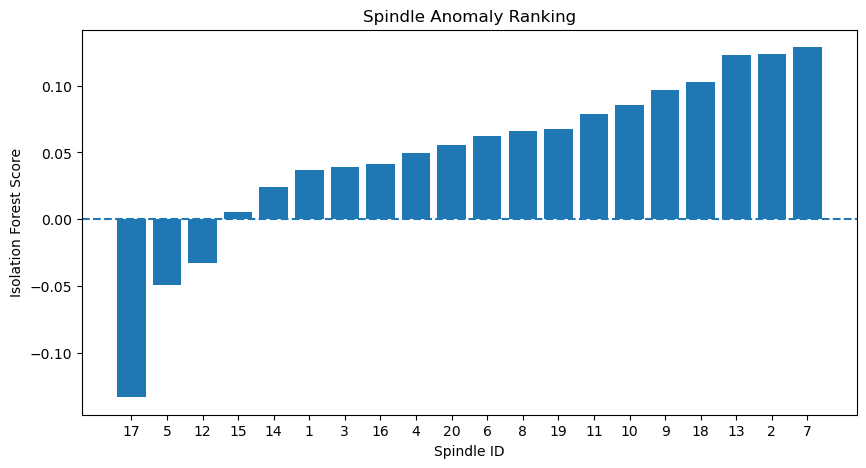

In [10]:
anomaly_plot = spindle_features.sort_values(
    "anomaly_score"
)

plt.figure(figsize=(10, 5))

plt.bar(
    anomaly_plot["spindle_id"].astype(str),
    anomaly_plot["anomaly_score"]
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Spindle ID")
plt.ylabel("Isolation Forest Score")
plt.title("Spindle Anomaly Ranking")

plt.show()

## 8. Synthetic Yarn-Quality Dataset

Because real synchronized process and yarn-quality data are not available in this prototype, a synthetic dataset is generated for demonstrating predictive-quality modeling.

The synthetic quality relationship is illustrative and should not be interpreted as a validated physical model of yarn quality.

In [11]:
np.random.seed(42)

n_samples = 1000

ml_data = pd.DataFrame({
    "fiber_strength": np.random.normal(30, 2, n_samples),
    "fiber_length": np.random.normal(29, 1.2, n_samples),
    "micronaire": np.random.normal(4.2, 0.3, n_samples),
    "humidity": np.random.normal(58, 4, n_samples),
    "average_speed_rpm": np.random.normal(16500, 800, n_samples),
    "total_end_breaks": np.random.poisson(2, n_samples),
    "downtime_seconds": np.random.randint(0, 25, n_samples)
})


ml_data["quality_score"] = (
    80
    + 0.5 * ml_data["fiber_strength"]
    + 0.3 * ml_data["fiber_length"]
    - 1.5 * ml_data["total_end_breaks"]
    - 0.4 * ml_data["downtime_seconds"]
    - 0.002 * abs(
        ml_data["average_speed_rpm"] - 16500
    )
    + np.random.normal(0, 2, n_samples)
)


ml_data["quality_status"] = np.where(
    ml_data["quality_score"] >= 90,
    "Good",
    "Defective"
)

ml_data["quality_status"].value_counts()

quality_status
Good         869
Defective    131
Name: count, dtype: int64

## 9. Predictive Quality Model

A Random Forest classifier is trained to estimate whether the simulated yarn-quality outcome is Good or Defective.

In [12]:
feature_columns = [
    "fiber_strength",
    "fiber_length",
    "micronaire",
    "humidity",
    "average_speed_rpm",
    "total_end_breaks",
    "downtime_seconds"
]

X = ml_data[feature_columns]
y = ml_data["quality_status"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [13]:
balanced_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

balanced_model.fit(
    X_train,
    y_train
)

y_pred_balanced = balanced_model.predict(
    X_test
)

print(
    classification_report(
        y_test,
        y_pred_balanced
    )
)

              precision    recall  f1-score   support

   Defective       0.62      0.19      0.29        26
        Good       0.89      0.98      0.93       174

    accuracy                           0.88       200
   macro avg       0.76      0.59      0.61       200
weighted avg       0.86      0.88      0.85       200



### Class-Imbalance Observation

The synthetic dataset contains substantially more Good samples than Defective samples. Therefore, overall accuracy alone is not sufficient for evaluation.

For manufacturing quality-control applications, recall for the Defective class is particularly important because false-negative predictions could allow defective production to pass without warning.

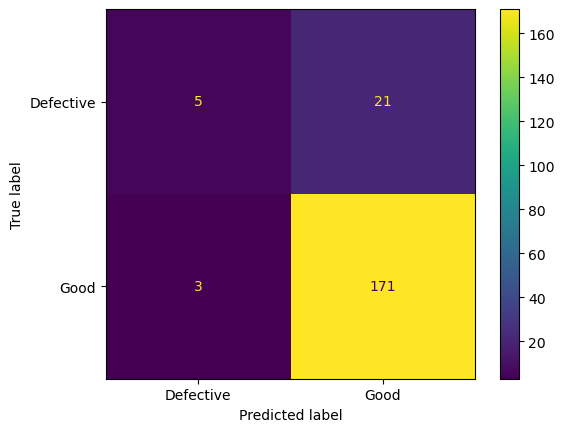

In [14]:
cm_balanced = confusion_matrix(
    y_test,
    y_pred_balanced,
    labels=["Defective", "Good"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_balanced,
    display_labels=["Defective", "Good"]
)

disp.plot()

plt.show()

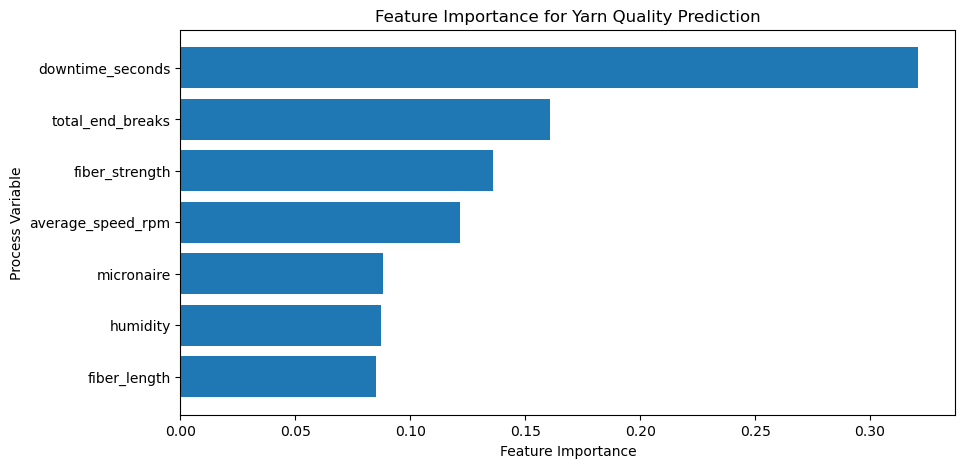

In [15]:
feature_importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": balanced_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

plt.figure(figsize=(10, 5))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Process Variable")
plt.title("Feature Importance for Yarn Quality Prediction")

plt.gca().invert_yaxis()

plt.show()

## 10. Process Degradation and Early Warning

A gradual degradation scenario is simulated to evaluate how predicted quality risk changes as operating conditions deteriorate over time.

In [16]:
np.random.seed(42)

degradation_data = []

fiber_strength = 31
fiber_length = 29.5
micronaire = 4.1
humidity = 58

base_speed = 16500


for t in range(100):

    degradation = t / 100

    current_speed = (
        base_speed
        + np.random.normal(0, 150)
        + degradation * 900
    )

    end_breaks = np.random.poisson(
        1 + degradation * 5
    )

    downtime = max(
        0,
        np.random.normal(
            2 + degradation * 18,
            2
        )
    )

    current_fiber_strength = (
        fiber_strength
        - degradation * 2
        + np.random.normal(0, 0.3)
    )

    current_humidity = (
        humidity
        + degradation * 5
        + np.random.normal(0, 1)
    )

    degradation_data.append({
        "time_step": t,
        "fiber_strength": current_fiber_strength,
        "fiber_length": fiber_length,
        "micronaire": micronaire,
        "humidity": current_humidity,
        "average_speed_rpm": current_speed,
        "total_end_breaks": end_breaks,
        "downtime_seconds": downtime
    })


degradation_df = pd.DataFrame(
    degradation_data
)


defective_index = list(
    balanced_model.classes_
).index("Defective")


degradation_df["defect_probability"] = (
    balanced_model.predict_proba(
        degradation_df[feature_columns]
    )[:, defective_index]
)

In [17]:
def risk_category(probability):

    if probability >= 0.60:
        return "HIGH"

    elif probability >= 0.30:
        return "MEDIUM"

    else:
        return "LOW"


degradation_df["risk_level"] = (
    degradation_df["defect_probability"]
    .apply(risk_category)
)


degradation_df["warning_flag"] = (
    degradation_df["defect_probability"] >= 0.30
).astype(int)


degradation_df["persistent_warning"] = (
    degradation_df["warning_flag"]
    .rolling(window=3)
    .sum()
    >= 3
)

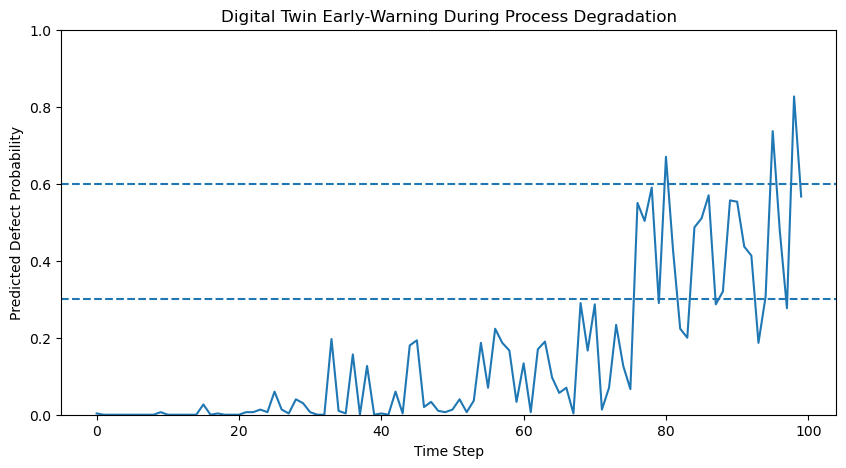

In [18]:
plt.figure(figsize=(10, 5))

plt.plot(
    degradation_df["time_step"],
    degradation_df["defect_probability"]
)

plt.axhline(
    0.30,
    linestyle="--"
)

plt.axhline(
    0.60,
    linestyle="--"
)

plt.xlabel("Time Step")
plt.ylabel("Predicted Defect Probability")
plt.title(
    "Digital Twin Early-Warning During Process Degradation"
)

plt.ylim(0, 1)

plt.show()

## 11. Live Digital Twin Simulation

The static process model is extended into a stateful live-style simulation. Each update cycle modifies spindle states and recalculates the current operating condition.

In [19]:
live_states = {}

for spindle_id in range(1, number_of_spindles + 1):

    live_states[spindle_id] = {
        "status": "Running",
        "downtime_remaining": 0
    }


def update_digital_twin():

    current_data = []

    for spindle_id in range(1, number_of_spindles + 1):

        state = live_states[spindle_id]

        health = spindle_health[spindle_id]
        probability = failure_probability[health]

        if state["downtime_remaining"] > 0:

            speed = 0
            status = "Stopped"

            state["downtime_remaining"] -= 1

        else:

            failure = random.random() < probability

            if failure:

                speed = 0
                status = "Stopped"

                state["downtime_remaining"] = random.randint(
                    2,
                    5
                )

            else:

                speed = random.randint(
                    15000,
                    18000
                )

                status = "Running"

        state["status"] = status

        current_data.append({
            "spindle_id": spindle_id,
            "health_condition": health,
            "speed_rpm": speed,
            "status": status
        })

    return pd.DataFrame(
        current_data
    )

## 12. Maintenance Prioritization

End-break frequency and cumulative downtime are tracked during live operation and combined into a simple health score for maintenance prioritization.

The health-score weights used here are heuristic demonstration values and are not validated industrial maintenance thresholds.

In [20]:
live_counters = {}

for spindle_id in range(1, number_of_spindles + 1):

    live_counters[spindle_id] = {
        "previous_status": "Running",
        "cumulative_downtime": 0,
        "total_end_breaks": 0
    }

## 13. Integrated Live Dashboard

The final dashboard combines current spindle state, machine utilization, cumulative end breaks, maintenance prioritization, and predicted yarn-quality risk in a single live-updating interface.

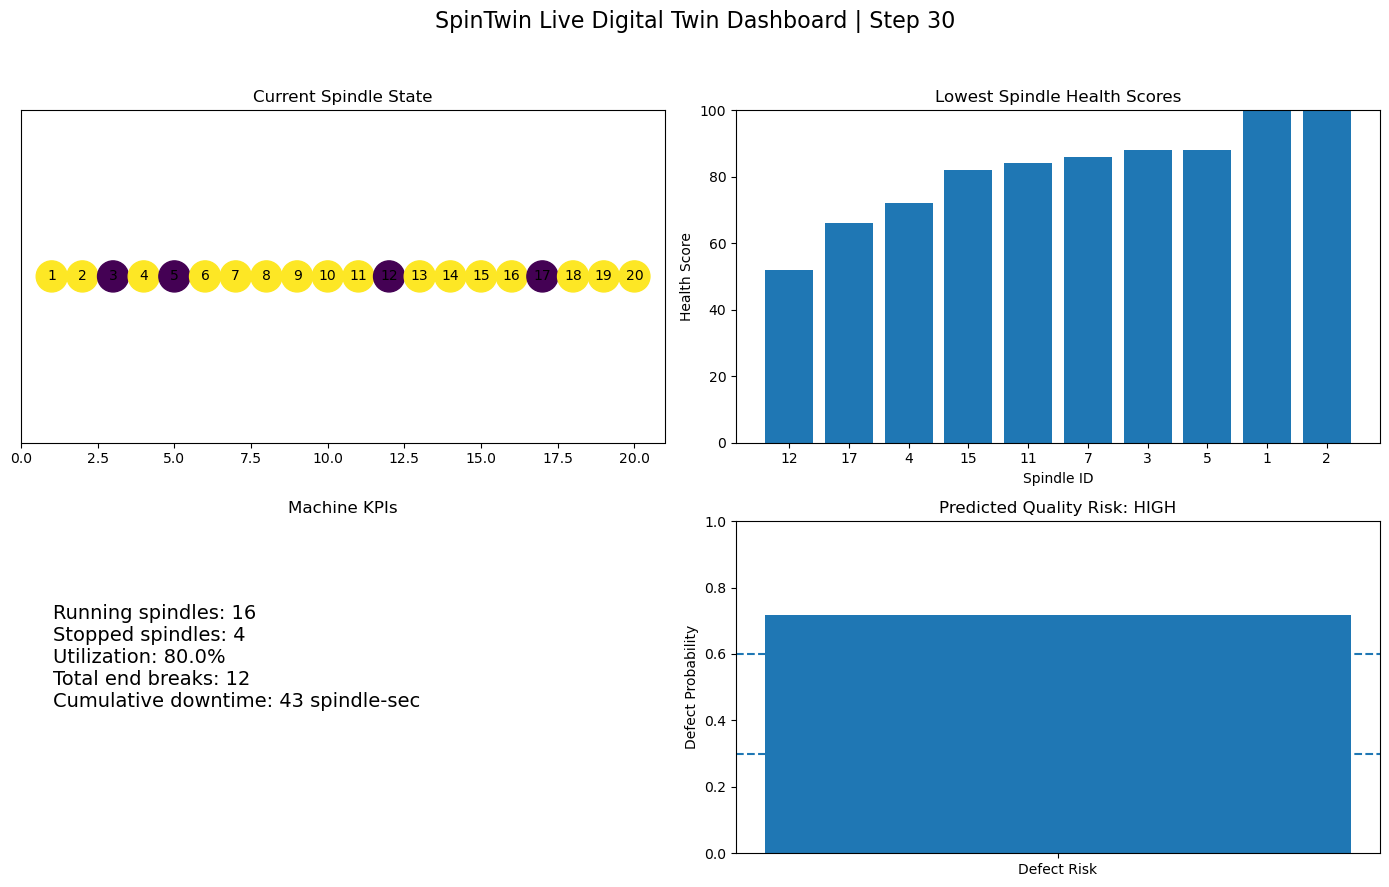

Stopped spindle IDs: [3, 5, 12, 17]
Top maintenance priority spindle: 12
Predicted defect probability: 71.67 %


In [21]:
# Store live monitoring history
live_history = []

for step in range(30):

    # -----------------------------------
    # 1. Update digital twin
    # -----------------------------------

    current_state = update_digital_twin()

    # -----------------------------------
    # 2. Update spindle counters
    # -----------------------------------

    for _, row in current_state.iterrows():

        spindle_id = int(row["spindle_id"])
        current_status = row["status"]

        previous_status = (
            live_counters[spindle_id]["previous_status"]
        )

        # Count a new end-break only when
        # the spindle changes from Running -> Stopped
        if (
            previous_status == "Running"
            and current_status == "Stopped"
        ):
            live_counters[spindle_id]["total_end_breaks"] += 1

        # Add one second of downtime
        if current_status == "Stopped":
            live_counters[spindle_id]["cumulative_downtime"] += 1

        # Update previous status
        live_counters[spindle_id]["previous_status"] = current_status


    # -----------------------------------
    # 3. Current machine metrics
    # -----------------------------------

    running_spindles = (
        current_state["status"] == "Running"
    ).sum()

    stopped_spindles = (
        current_state[
            current_state["status"] == "Stopped"
        ]["spindle_id"]
        .tolist()
    )

    utilization = (
        running_spindles
        / number_of_spindles
    ) * 100


    total_end_breaks = sum(
        counter["total_end_breaks"]
        for counter in live_counters.values()
    )

    cumulative_downtime = sum(
        counter["cumulative_downtime"]
        for counter in live_counters.values()
    )


    # -----------------------------------
    # 4. Current average spindle speed
    # -----------------------------------

    avg_speed = (
        current_state[
            current_state["speed_rpm"] > 0
        ]["speed_rpm"]
        .mean()
    )

    if pd.isna(avg_speed):
        avg_speed = 0


    # -----------------------------------
    # 5. Simulated material/environment data
    # -----------------------------------

    current_fiber_strength = np.random.normal(
        30,
        2
    )

    current_fiber_length = np.random.normal(
        29,
        1.2
    )

    current_micronaire = np.random.normal(
        4.2,
        0.3
    )

    current_humidity = np.random.normal(
        58,
        4
    )


    # -----------------------------------
    # 6. Quality-risk prediction
    # -----------------------------------

    live_process_state = pd.DataFrame({
        "fiber_strength": [
            current_fiber_strength
        ],
        "fiber_length": [
            current_fiber_length
        ],
        "micronaire": [
            current_micronaire
        ],
        "humidity": [
            current_humidity
        ],
        "average_speed_rpm": [
            avg_speed
        ],
        "total_end_breaks": [
            total_end_breaks
        ],
        "downtime_seconds": [
            cumulative_downtime
        ]
    })


    probability = (
        balanced_model.predict_proba(
            live_process_state[feature_columns]
        )[0, defective_index]
    )


    if probability >= 0.60:
        quality_risk = "HIGH"

    elif probability >= 0.30:
        quality_risk = "MEDIUM"

    else:
        quality_risk = "LOW"


    # -----------------------------------
    # 7. Maintenance-health table
    # -----------------------------------

    maintenance_rows = []

    for spindle_id in range(
        1,
        number_of_spindles + 1
    ):

        counter = live_counters[spindle_id]

        current_row = current_state[
            current_state["spindle_id"]
            == spindle_id
        ].iloc[0]


        health_score = (
            100
            - 8 * counter["total_end_breaks"]
            - 2 * counter["cumulative_downtime"]
        )

        health_score = max(
            health_score,
            0
        )


        if health_score >= 80:
            maintenance_condition = "Healthy"
            maintenance_priority = "LOW"

        elif health_score >= 60:
            maintenance_condition = "Watch"
            maintenance_priority = "MEDIUM"

        else:
            maintenance_condition = "Maintenance Required"
            maintenance_priority = "HIGH"


        maintenance_rows.append({
            "spindle_id": spindle_id,
            "current_status": current_row["status"],
            "current_speed_rpm": current_row["speed_rpm"],
            "total_end_breaks": counter["total_end_breaks"],
            "cumulative_downtime": counter["cumulative_downtime"],
            "health_score": health_score,
            "maintenance_condition": maintenance_condition,
            "maintenance_priority": maintenance_priority
        })


    maintenance_live_df = pd.DataFrame(
        maintenance_rows
    )

    maintenance_live_df = (
        maintenance_live_df
        .sort_values(
            [
                "health_score",
                "total_end_breaks"
            ],
            ascending=[
                True,
                False
            ]
        )
        .reset_index(drop=True)
    )


    # -----------------------------------
    # 8. Save this time step in history
    # -----------------------------------

    live_history.append({
        "step": step + 1,
        "running_spindles": int(running_spindles),
        "stopped_spindles": len(stopped_spindles),
        "utilization_percent": utilization,
        "total_end_breaks": total_end_breaks,
        "cumulative_downtime": cumulative_downtime,
        "defect_probability": probability,
        "quality_risk": quality_risk
    })


    # -----------------------------------
    # 9. Prepare dashboard
    # -----------------------------------

    clear_output(wait=True)

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(14, 9)
    )

    fig.suptitle(
        f"SpinTwin Live Digital Twin Dashboard | Step {step + 1}",
        fontsize=16
    )


    # -----------------------------------
    # Panel 1: Current spindle state
    # -----------------------------------

    current_state["status_code"] = (
        current_state["status"]
        .map({
            "Running": 1,
            "Stopped": 0
        })
    )


    axes[0, 0].scatter(
        current_state["spindle_id"],
        [1] * len(current_state),
        s=500,
        c=current_state["status_code"]
    )


    for _, row in current_state.iterrows():

        axes[0, 0].text(
            row["spindle_id"],
            1,
            str(int(row["spindle_id"])),
            ha="center",
            va="center"
        )


    axes[0, 0].set_title(
        "Current Spindle State"
    )

    axes[0, 0].set_xlim(
        0,
        number_of_spindles + 1
    )

    axes[0, 0].set_ylim(
        0.8,
        1.2
    )

    axes[0, 0].set_yticks([])


    # -----------------------------------
    # Panel 2: Maintenance ranking
    # -----------------------------------

    top_maintenance = (
        maintenance_live_df
        .head(10)
    )


    axes[0, 1].bar(
        top_maintenance[
            "spindle_id"
        ].astype(str),
        top_maintenance[
            "health_score"
        ]
    )


    axes[0, 1].set_title(
        "Lowest Spindle Health Scores"
    )

    axes[0, 1].set_xlabel(
        "Spindle ID"
    )

    axes[0, 1].set_ylabel(
        "Health Score"
    )

    axes[0, 1].set_ylim(
        0,
        100
    )


    # -----------------------------------
    # Panel 3: Machine KPIs
    # -----------------------------------

    axes[1, 0].axis(
        "off"
    )


    kpi_text = (
        f"Running spindles: {running_spindles}\n"
        f"Stopped spindles: {len(stopped_spindles)}\n"
        f"Utilization: {utilization:.1f}%\n"
        f"Total end breaks: {total_end_breaks}\n"
        f"Cumulative downtime: {cumulative_downtime} spindle-sec"
    )


    axes[1, 0].text(
        0.05,
        0.75,
        kpi_text,
        fontsize=14,
        va="top"
    )


    axes[1, 0].set_title(
        "Machine KPIs"
    )


    # -----------------------------------
    # Panel 4: Predicted quality risk
    # -----------------------------------

    axes[1, 1].bar(
        ["Defect Risk"],
        [probability]
    )


    axes[1, 1].axhline(
        0.30,
        linestyle="--"
    )

    axes[1, 1].axhline(
        0.60,
        linestyle="--"
    )


    axes[1, 1].set_ylim(
        0,
        1
    )

    axes[1, 1].set_ylabel(
        "Defect Probability"
    )


    axes[1, 1].set_title(
        f"Predicted Quality Risk: {quality_risk}"
    )


    # -----------------------------------
    # 10. Finish and save dashboard
    # -----------------------------------

    plt.tight_layout(
        rect=[0, 0, 1, 0.95]
    )


    plt.savefig(
        "spintwin_dashboard.png",
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()

    plt.close(fig)


    # -----------------------------------
    # Console information
    # -----------------------------------

    print(
        "Stopped spindle IDs:",
        stopped_spindles
    )

    print(
        "Top maintenance priority spindle:",
        int(
            maintenance_live_df.iloc[0][
                "spindle_id"
            ]
        )
    )

    print(
        "Predicted defect probability:",
        round(
            probability * 100,
            2
        ),
        "%"
    )


    time.sleep(1)

In [22]:
live_history_df = pd.DataFrame(
    live_history
)

print(
    "Number of live monitoring records:",
    len(live_history_df)
)

live_history_df.head()

Number of live monitoring records: 30


,step,running_spindles,stopped_spindles,utilization_percent,total_end_breaks,cumulative_downtime,defect_probability,quality_risk
0,1,20,0,100.0,0,0,0.0,LOW
1,2,19,1,95.0,1,1,0.0,LOW
2,3,19,1,95.0,1,2,0.0,LOW
3,4,19,1,95.0,1,3,0.0,LOW
4,5,19,1,95.0,1,4,0.0,LOW


In [23]:
# Export final project results

maintenance_live_df.to_csv(
    "spindle_maintenance_summary.csv",
    index=False
)

spindle_features.to_csv(
    "spindle_anomaly_results.csv",
    index=False
)

ml_data.to_csv(
    "synthetic_quality_dataset.csv",
    index=False
)

live_history_df.to_csv(
    "live_digital_twin_history.csv",
    index=False
)


print("Project outputs saved successfully.")

Project outputs saved successfully.


In [24]:
import os

project_files = [
    "spindle_maintenance_summary.csv",
    "spindle_anomaly_results.csv",
    "synthetic_quality_dataset.csv",
    "live_digital_twin_history.csv",
    "spintwin_dashboard.png"
]

for file in project_files:

    if os.path.exists(file):
        print("✓", file)

    else:
        print("✗ NOT FOUND:", file)

✓ spindle_maintenance_summary.csv
✓ spindle_anomaly_results.csv
✓ synthetic_quality_dataset.csv
✓ live_digital_twin_history.csv
✓ spintwin_dashboard.png


## 14. Results

The SpinTwin prototype demonstrates an end-to-end simulation-based digital-twin workflow for ring-spinning manufacturing.

The implemented system includes:

- spindle-level operating-state simulation,
- stateful time-series monitoring,
- end-break event detection,
- downtime tracking,
- machine-utilization analysis,
- unsupervised spindle anomaly detection,
- synthetic yarn-quality modeling,
- process-degradation simulation,
- persistent early-warning logic,
- spindle health scoring,
- maintenance prioritization, and
- an integrated live monitoring dashboard.

The prototype shows how machine-state information, operational analytics, and predictive models can be integrated into a unified manufacturing decision-support workflow.

Because the current implementation uses simulated process and quality data, these results demonstrate system architecture and analytical workflow rather than validated industrial performance.

## 15. Limitations

1. The current system is simulation-based and is not connected to a physical ring frame.
2. Process and yarn-quality data are synthetic rather than collected from an industrial production line.
3. The predictive-quality relationship is generated using an illustrative synthetic equation.
4. Maintenance scores and warning thresholds are heuristic and have not been industrially validated.
5. Spindle-speed behavior is simplified compared with real ring-frame dynamics.
6. The current prototype does not include industrial communication protocols such as OPC UA or MQTT.
7. Only a limited number of machine, material, and environmental variables are represented.
8. Machine-learning performance obtained using the synthetic dataset should not be interpreted as real industrial predictive accuracy.
9. The live quality model currently uses simplified aggregated process indicators rather than a fully synchronized process-quality data pipeline.